| Size (sqft) | Number of Bedrooms  | Number of floors | Age of  Home | Price (1000s dollars)  |   
| ----------------| ------------------- |----------------- |--------------|-------------- |  
| 2104            | 5                   | 1                | 45           | 460           |  
| 1416            | 3                   | 2                | 40           | 232           |  
| 852             | 2                   | 1                | 35           | 178           |  

Number of training example are : 3
X Shape: (3, 4), X Type:<class 'numpy.ndarray'>)
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
y Shape: (3,), y Type:<class 'numpy.ndarray'>)
[460 232 178]


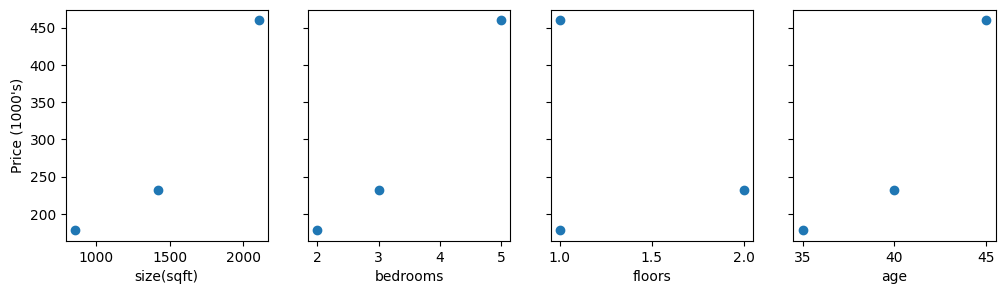

In [ ]:
#Model Representation

import numpy as np
import matplotlib.pyplot as plt

x_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])
print(f"Number of training example are : {x_train.shape[0]}")
# data is stored in numpy array/matrix
print(f"X Shape: {x_train.shape}, X Type:{type(x_train)})")
print(x_train)
print(f"y Shape: {y_train.shape}, y Type:{type(y_train)})")
print(y_train)

X_features = ['F1','F2','F3','F4']
fig,ax=plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_train[:,i],y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Target")
plt.show()



In [69]:
#Model Function 
# Let initial w & b
w = np.array([100,100,100,100])
b = 100

# Using 2 Loops - Brute Force : compute_model_output For Single Row
# def compute_model_output_1_row(x, w, b):
#     m = x.shape[0]
#     predict = 0
#     for i in range(m):
#         predict += w[i] * x[i]
#     predict += b
#     return predict

# m = X_train.shape[0]
# f_wb = []
# for i in range(m):# each row in table
#     f_wb.append(compute_model_output_1_row(X_train[i], w, b))

# ** Single Prediction Vector : Using Dot Product - Optimized
def compute_model_output_dot(x, w, b):
    return np.dot(x, w)+b

f_wb = compute_model_output_dot(x_train, w, b)
print(f_wb)
print("Actual ", y_train)



[215600 146200  89100]
Actual  [460 232 178]


In [70]:
#Fix w and b manutally to see how our model performs
# Optimzied = b = -0.00 x = [ 0.2   0.   -0.01 -0.07]   find using Gradient Descent

f_wb = compute_model_output_dot(x_train, np.array([ 0.2, 0.0 ,  -0.01, -0.07]) , -0.00)
print(f_wb)
print("Actual ", y_train)


[417.64 280.38 167.94]
Actual  [460 232 178]


In [71]:
# Cost Function

def compute_cost_nfeatures(x, y, w, b):
    m = x.shape[0]
    loss_sum = 0
    for i in range(m):
        predict = np.dot(x[i], w) + b # single feature : w*x[i] + b #y^
        loss = (predict - y[i]) ** 2
        loss_sum += loss
    cost = loss_sum * (1/(2*m))
    return cost

cost = compute_cost_nfeatures(x_train, y_train, w, b) #Inital 
print("Cost intial : ",cost)
cost = compute_cost_nfeatures(x_train, y_train, np.array([ 0.2, 0.0 ,  -0.01, -0.07]) , -0.00) # Fixed manually
print("Cost manually fixed : ",cost)



Cost intial :  12583166451.333332
Cost manually fixed :  706.0329333333326


In [72]:
# Gradients - return dj_dw for each feature + 1 jd_jb

def compute_gradient_nfeatures(x, y, w, b):
    # m = x.shape[0]
    # n = x.shape[1]
    m, n = x.shape
    dj_dw = np.zeros(n) # or np.zeros((n,))
    dj_db = 0
    for i in range(m):
        predict = np.dot(x[i], w) + b # predict using all feature in a row
        loss = predict - y[i] # loss for all features in a row
        # update dj_dw for each feature
        for j in range(n):
            dj_dw[j] += loss*x[i,j] # loss from all features * value form each single feature
        dj_db += loss
    
    dj_dw/=m
    dj_db/=m
    return dj_dw, dj_db

print("x_train:", x_train)
print("y_train:", y_train)
print("m =", x_train.shape[0])

gradient_w, gradient_b = compute_gradient_nfeatures(x_train, y_train, w, b)
print(f"Step 1 -> Gradient: ({gradient_w}, {gradient_b})")

        

x_train: [[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
y_train: [460 232 178]
m = 3
Step 1 -> Gradient: ([2.45035597e+08 5.63816000e+05 1.98666000e+05 6.21076333e+06], 150010.0)


[0. 0. 0.]
Iteration    0: Cost  2529.46 dj_dw : [-4.82669333e+05 -1.11733333e+03 -3.67333333e+02 -1.20700000e+04] w : [2.41334667e-01 5.58666667e-04 1.83666667e-04 6.03500000e-03]
Iteration 1000: Cost   686.69 dj_dw : [ -3.51882455  -6.54526579  22.66262662 138.80156152] w : [ 0.20396745  0.00375246 -0.01126004 -0.0659308 ]
Iteration 2000: Cost   677.19 dj_dw : [ -3.36486166  -6.50164907  22.35112103 132.7290655 ] w : [ 0.20568804  0.0070141  -0.02251282 -0.13380069]
Iteration 3000: Cost   668.48 dj_dw : [ -3.2175952   -6.45990083  22.05308391 126.92068518] w : [ 0.20733335  0.0102544  -0.03361325 -0.19870091]
Iteration 4000: Cost   660.50 dj_dw : [ -3.07673392  -6.41993978  21.76792949 121.36493333] w : [ 0.20890664  0.01347428 -0.04456791 -0.26076063]
Iteration 5000: Cost   653.19 dj_dw : [ -2.94199924  -6.38168822  21.49509747 116.05082238] w : [ 0.21041104  0.01667461 -0.05538309 -0.3201034 ]
Iteration 6000: Cost   646.49 dj_dw : [ -2.81312469  -6.34507179  21.23405192 110.9678426

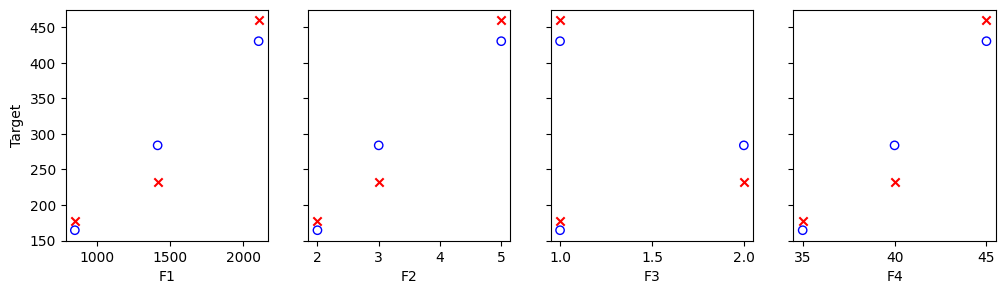

In [ ]:
# Gradient Descent with multiple features
import copy
import math

def gradient_descent(x, y, w, b, alpha, epochs, compute_cost_nfeatures, compute_gradient_nfeatures):
    w = copy.deepcopy(w)
    b = copy.deepcopy(b)
    m, n = x.shape
    cost_history = []
    params_history = []

    for i in range(epochs):
        #Calc Gradients
        dj_dw, dj_db = compute_gradient_nfeatures(x, y, w, b)
        #Update Parameters
        w -= alpha * dj_dw # Update each weight using its corresponding gradient, Element-wise update: w[j] = w[j] - alpha * dj_dw[j]
        b -= alpha * dj_db

        # Resource exacution
        if i < 10000:
            cost = compute_cost_nfeatures(x, y, w, b)
            cost_history.append(cost)
            params_history.append([w.copy(),b]) # as w is array, every iteration wil store same reference so use copy
        #Print Status
        if i% math.ceil(epochs/10) == 0:# after each 10 percent of epochs
            print(f"Iteration {i:4d}: Cost {cost_history[-1]:8.2f} dj_dw : {dj_dw} w : {w}")

    return w, b, cost_history, params_history


# w_init = np.array([100.0,100.0,100.0,100.0])
# b_init = 100
# w_init = np.array([10.0,10.0,10.0,10.0])
# b_init = 10
w_init = np.array([0.0,0.0,0.0,0.0])
b_init = 0

epochs = 10000
alpha = 5.0e-7 # -2 gives nan

initial_f_wb = compute_model_output_dot(x_train, w_init, b_init)
print(initial_f_wb)

w_final, b_final , cost_history, param_history = gradient_descent(x_train, y_train, w_init, b_init, alpha, epochs, compute_cost_nfeatures, compute_gradient_nfeatures)
print(f"Final (w,b) found by gradient descent : {w_final, b_final}")

final_f_wb = compute_model_output_dot(x_train, w_final, b_final)
print(final_f_wb)


X_features = ['F1','F2','F3','F4']
fig,ax=plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_train[:,i],y_train
                  ,marker='x',
                  c='r',
                  label='Actual')
    ax[i].scatter(x_train[:,i],final_f_wb
                  ,marker='o',
                  facecolors='none',
                  edgecolors='b',
                  label='Prediction')
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Target")
plt.show()
#for curr case - as we kep w and b as 100 large for all... cost is too much ...  gradients are jusping too much for reduceing cost ... thus we need to reduce learning rate ... if reducing learning rate slow downs convergence ... we need to increae epocs.


#Note - bad Traing- Your Learning rate is too high
# Cost
# 5000
# 90000
# 400000000
# 7e20
# inf
# nan

# if due to slow learning rate,  convergence in csot is slow .. incraee epochs

# Situation	Learning Rate
# Raw features (different scales)	1e-6 to 1e-4
# Normalized features	0.01
# Standardized data	0.01 to 0.1
# Adaptive optimizers (Adam, RMSProp)	0.001 is a common starting point


#PROFESSIONAL WORKFLOW
# Normalize Features
# ↓
# Initialize
# w = 0
# b = 0
# ↓
#   Try 
# alpha = 0.1
# ↓
# If diverges
# ↓
# 0.01
# ↓
# Still diverges
# ↓
# 0.001
# ↓
# Converges
# ↓
# Done




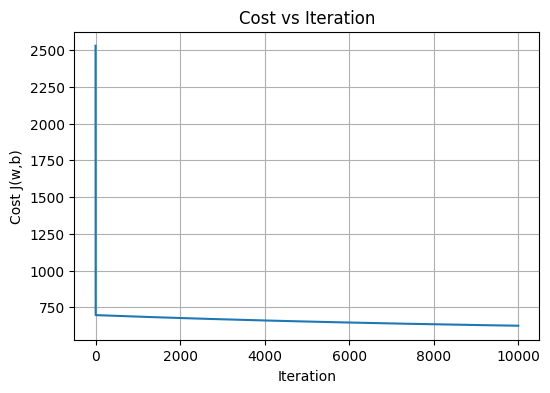

In [94]:
# plot cost versus iteration  
def plot_cost_history(cost_history):
    plt.figure(figsize=(6,4))

    plt.plot(cost_history)

    plt.title("Cost vs Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Cost J(w,b)")

    plt.grid(True)
    plt.show()

plot_cost_history(cost_history)

In [ ]:
# =============================================================================
# Why does a slightly larger learning rate (alpha) cause NaN?
# =============================================================================
#
# Gradient Descent updates the weights using:
#
#       w = w - alpha * gradient
#
# If alpha (learning rate) is too large, the weight update becomes huge.
# Huge weights produce huge predictions, which produce even larger gradients.
# This creates an endless cycle until the numbers overflow.
#
# -----------------------------------------------------------------------------
# Example (using our housing dataset)
# -----------------------------------------------------------------------------
#
# Initial weights:
#
#       w = [100, 100, 100, 100]
#       b = 100
#
# First training example:
#
#       x = [2104, 5, 1, 45]
#       y = 460
#
# -----------------------------------------------------------------------------
# Step 1: Compute prediction
# -----------------------------------------------------------------------------
#
# prediction =
#
#   (2104 × 100) +
#   (5 × 100) +
#   (1 × 100) +
#   (45 × 100) +
#   100
#
# = 210400 + 500 + 100 + 4500 + 100
#
# = 215600
#
#
# -----------------------------------------------------------------------------
# Step 2: Compute prediction error
# -----------------------------------------------------------------------------
#
# error = prediction - actual
#
#       = 215600 - 460
#
#       = 215140
#
# The prediction is already far away from the true value.
#
#
# -----------------------------------------------------------------------------
# Step 3: Compute gradient
# -----------------------------------------------------------------------------
#
# Gradient for each feature is:
#
#       gradient = error × feature_value
#
# Example for the Size feature:
#
#       gradient
#       = 215140 × 2104
#
#       = 452,654,560
#
# Notice how the large feature value (2104) makes the gradient enormous.
#
#
# -----------------------------------------------------------------------------
# Step 4: Update the weight
# -----------------------------------------------------------------------------
#
# Gradient Descent update:
#
#       w = w - alpha × gradient
#
# Suppose:
#
#       alpha = 0.01
#
# Then
#
#       w
#       = 100 - (0.01 × 452,654,560)
#
#       = 100 - 4,526,545.6
#
#       ≈ -4,526,446
#
# The weight jumps from 100 to about -4.5 million in ONE iteration!
#
#
# -----------------------------------------------------------------------------
# Step 5: Next prediction
# -----------------------------------------------------------------------------
#
# Now use this huge negative weight.
#
# Contribution from Size feature:
#
#       2104 × (-4,526,446)
#
#       ≈ -9.5 billion
#
# The prediction is now billions away from the correct answer.
#
#
# -----------------------------------------------------------------------------
# Step 6: Next gradient
# -----------------------------------------------------------------------------
#
# Since
#
#       gradient = error × feature
#
# and the error is now billions,
#
# the next gradient becomes
#
#       billions × 2104
#
#       ≈ trillions
#
#
# -----------------------------------------------------------------------------
# Step 7: Next update
# -----------------------------------------------------------------------------
#
# Weight update becomes
#
#       w = w - alpha × trillions
#
# Now the weights become trillions.
#
# The next prediction becomes quadrillions.
#
# The next gradient becomes even larger.
#
# This keeps exploding every iteration.
#
#
# -----------------------------------------------------------------------------
# Eventually...
# -----------------------------------------------------------------------------
#
# Floating point numbers in Python have a maximum value of roughly
#
#       1.79 × 10^308
#
# Once calculations exceed this limit,
#
# Python stores the value as
#
#       inf      (infinity)
#
# Later calculations may produce
#
#       inf - inf
#
# or
#
#       inf / inf
#
# These operations are mathematically undefined.
#
# Python therefore returns
#
#       NaN
#
# which means
#
#       Not a Number
#
#
# -----------------------------------------------------------------------------
# Summary
# -----------------------------------------------------------------------------
#
# Large alpha
#      ↓
# Huge weight updates
#      ↓
# Huge predictions
#      ↓
# Huge errors
#      ↓
# Huge gradients
#      ↓
# Even larger weight updates
#      ↓
# Overflow (inf)
#      ↓
# Undefined operations (inf - inf)
#      ↓
# NaN
#
# This is why choosing an appropriate learning rate is very important.
# =============================================================================